In [ ]:
#Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Carga  del archivo
data = pd.read_excel('Ventas_por_Asesor_limpio.xlsx')
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,38
0,PEDRO GONZALEZ ESPINDOLA,0,0,1,2,0,7,2,3,3,...,4,0,88,42,22,25,45,2,21,18
1,VICTOR MANUEL SANCHEZ ARRO,0,0,0,0,1,1,3,0,2,...,3,2,88,42,11,25,51,31,26,18
2,MIGUEL ANGEL SONDEREGGER,0,0,0,1,2,7,5,2,2,...,0,0,28,6,27,1,1,25,0,17
3,JOSE ANTONIO LICONA MENDE,1,0,0,2,0,0,0,3,2,...,9,1,98,1,10,4,35,4,53,1
4,JAIME GONZALEZ CORONA,0,2,3,5,2,3,3,3,4,...,0,0,25,8,25,2,0,30,0,17


In [ ]:

columnas_numericas = data.select_dtypes(include='number').columns
columnas_numericas

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38],
      dtype='int64')

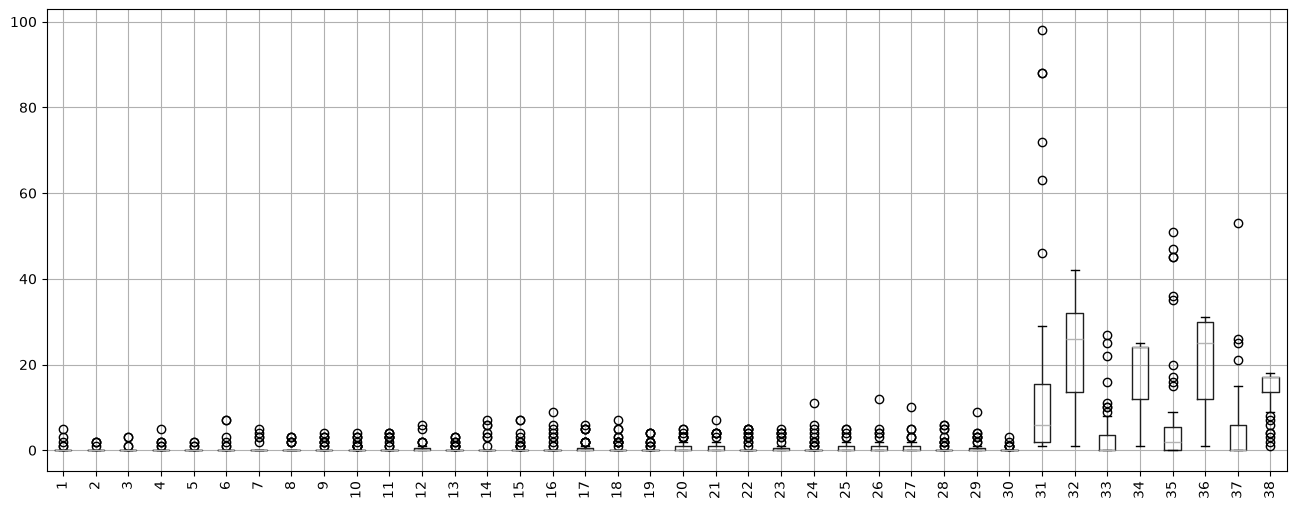

In [4]:
#Diagrama de caja por cada columna
data.boxplot(column=list(columnas_numericas), figsize=(16,6))
plt.xticks(rotation=90)
plt.show()

In [ ]:
# copia del df
data2 = data.copy()

In [ ]:
# Q1, Q3 y el rango intercuartilico por columna
for col in columnas_numericas:
    Q1 = data2[col].quantile(0.25)
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    data2[col] = data2[col].clip(limite_inferior, limite_superior)

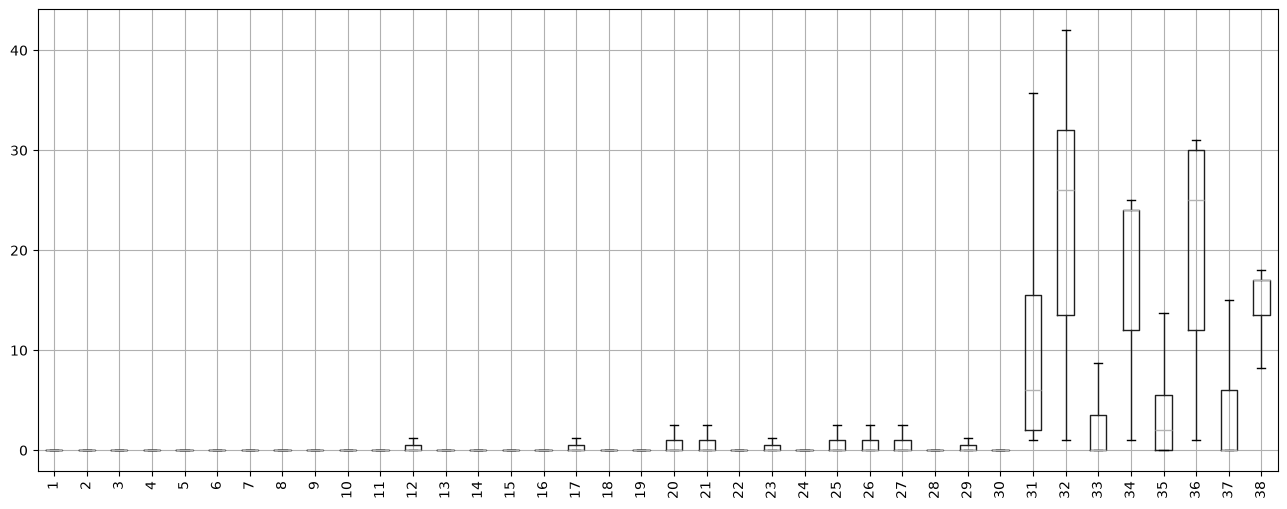

In [7]:
data2.boxplot(column=list(columnas_numericas), figsize=(16,6))
plt.xticks(rotation=90)
plt.show()

In [ ]:
#exprtamos el df limpio
data2.to_excel("Ventas_por_Asesor_sin_outliers.xlsx", index=False)